# CLASSIFICATION

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import StackingRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBClassifier
from xgboost import XGBRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Dataset

In [2]:
df = pd.read_csv("clean_data.csv")

df.head()

,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32.0,3,0,2,2,0,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,17.0,3,0,2,2,4,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,25.0,3,1,0,0,4,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,26.0,2,1,2,1,2,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,26.0,2,2,3,0,0,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4


## Features and Target

In [3]:
X = df.drop(["completion_status"],axis=1)

y = df["completion_status"]

## Train Test Split

In [4]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

## Base Model

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

gb = GradientBoostingClassifier(
    random_state=42
)

xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

## Hard Voting

In [6]:
hard_vote = VotingClassifier(

    estimators=[
        ("rf",rf),
        ("gb",gb),
        ("xgb",xgb)
    ],
    voting="hard"
)

hard_vote.fit(X_train,y_train)
hard_pred=hard_vote.predict(X_test)

## Hard Voting Evaluation

In [7]:
hard_accuracy=accuracy_score(y_test,hard_pred)
hard_precision=precision_score(y_test,hard_pred)
hard_recall=recall_score(y_test,hard_pred)
hard_f1=f1_score(y_test,hard_pred)

print("Accuracy :",hard_accuracy)
print("Precision :",hard_precision)
print("Recall :",hard_recall)
print("F1 :",hard_f1)

Accuracy : 0.8423076923076923
Precision : 0.8021108179419525
Recall : 0.7735368956743003
F1 : 0.7875647668393783


## Soft Voting

In [8]:
soft_vote=VotingClassifier(

    estimators=[
        ("rf",rf),
        ("gb",gb),
        ("xgb",xgb)
    ],

    voting="soft"
)

soft_vote.fit(X_train,y_train)
soft_pred=soft_vote.predict(X_test)
soft_prob=soft_vote.predict_proba(X_test)[:,1]

In [9]:
soft_accuracy=accuracy_score(y_test,soft_pred)
soft_precision=precision_score(y_test,soft_pred)
soft_recall=recall_score(y_test,soft_pred)
soft_f1=f1_score(y_test,soft_pred)
soft_auc=roc_auc_score(y_test,soft_prob)

print("Accuracy :",soft_accuracy)
print("Precision :",soft_precision)
print("Recall :",soft_recall)
print("F1 :",soft_f1)
print("ROC AUC :",soft_auc)

Accuracy : 0.8317307692307693
Precision : 0.7809278350515464
Recall : 0.7709923664122137
F1 : 0.7759282970550576
ROC AUC : 0.9012903555655186


## ROC Curve

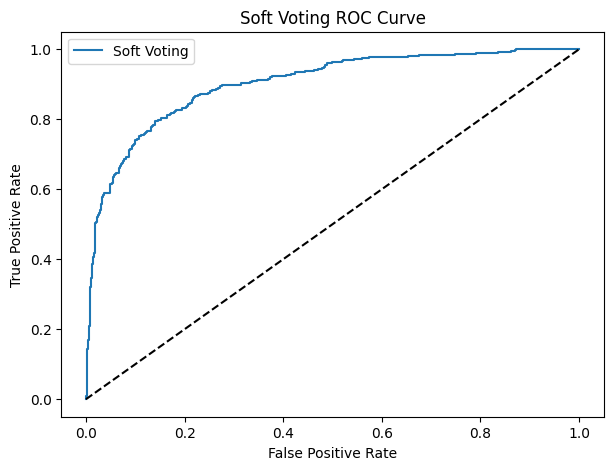

In [10]:
soft_fpr,soft_tpr,_=roc_curve(y_test,soft_prob)

plt.figure(figsize=(7,5))
plt.plot(soft_fpr,soft_tpr,label="Soft Voting")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Soft Voting ROC Curve")
plt.legend()
plt.show()

# Stacking Classifier

In [11]:
stack=StackingClassifier(

    estimators=[
        ("rf",rf),
        ("gb",gb),
        ("xgb",xgb)
    ],

    final_estimator=LogisticRegression(),
    cv=5
)

stack.fit(X_train,y_train)
stack_pred=stack.predict(X_test)
stack_prob=stack.predict_proba(X_test)[:,1]

In [12]:
stack_accuracy=accuracy_score(y_test,stack_pred)
stack_precision=precision_score(y_test,stack_pred)
stack_recall=recall_score(y_test,stack_pred)
stack_f1=f1_score(y_test,stack_pred)
stack_auc=roc_auc_score(y_test,stack_prob)

print("Accuracy :",stack_accuracy)
print("Precision :",stack_precision)
print("Recall :",stack_recall)
print("F1 :",stack_f1)
print("ROC AUC :",stack_auc)

Accuracy : 0.8346153846153846
Precision : 0.7885117493472585
Recall : 0.7684478371501272
F1 : 0.7783505154639175
ROC AUC : 0.9034887973854667


## Confusion Matrix

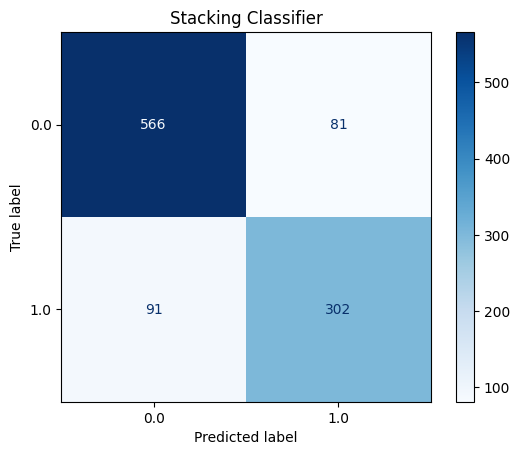

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    stack_pred,
    cmap="Blues"
)

plt.title("Stacking Classifier")
plt.show()

# Regression

## Features and Target

In [14]:
X=df.drop(["final_score"],axis=1)

y=df["final_score"]

## Train Test Split

In [15]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

## Base model

In [16]:
rf=RandomForestRegressor(random_state=42)

gb=GradientBoostingRegressor(random_state=42)

xgb=XGBRegressor(random_state=42)

## Stacking Regressor

In [17]:
stack_reg=StackingRegressor(

    estimators=[
        ("rf",rf),
        ("gb",gb),
        ("xgb",xgb)
    ],

    final_estimator=LinearRegression(),
    cv=5
)

stack_reg.fit(X_train,y_train)
stack_pred=stack_reg.predict(X_test)

In [18]:
stack_mae=mean_absolute_error(y_test,stack_pred)
stack_rmse=np.sqrt(mean_squared_error(y_test,stack_pred))
stack_r2=r2_score(y_test,stack_pred)

print("MAE :",stack_mae)
print("RMSE :",stack_rmse)
print("R2 :",stack_r2)

MAE : 6.626836247784953
RMSE : 8.27303871022338
R2 : 0.633679461714747


## Actual vs Predicted

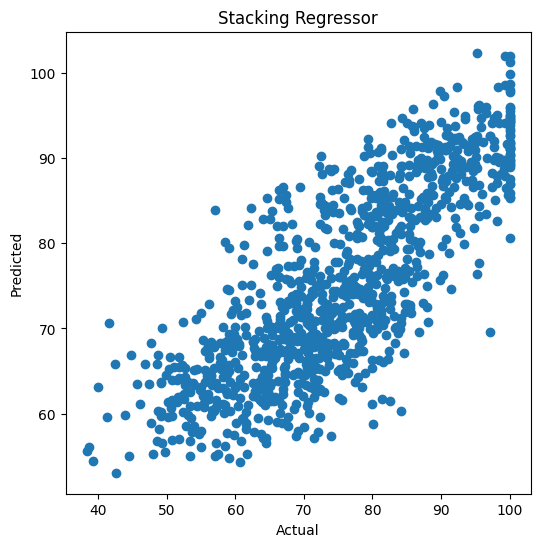

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,stack_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Stacking Regressor")
plt.show()

# Conclusion

Hard Voting: Combines predictions using majority voting and is simple and robust.

Soft Voting: Uses class probabilities from all base models and often performs better than hard voting because it considers prediction confidence.

Stacking Classifier: Learns how to combine the strengths of the base classifiers using a Logistic Regression meta-learner, which often gives the best classification performance.

Stacking Regressor: Uses predictions from multiple regressors as inputs to a Linear Regression meta-learner, usually producing more accurate score predictions than individual ensemble models.

The final comparison tables allow you to identify the best-performing classification model (highest Accuracy/F1/ROC-AUC) and the best-performing regression model (highest R² with lowest MAE and RMSE), satisfying the project requirements.